In [1]:
import pandas as pd
import numpy as np

# Load the data without using header, then assign correct column names
df = pd.read_csv("../nigeria.csv", skiprows=16, header=None)

# Assign the correct column names manually
df.columns = ['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 
              'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']

print("✅ Data loaded and columns assigned successfully!")
print(f"Shape: {df.shape}")
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

✅ Data loaded and columns assigned successfully!
Shape: (4093, 12)

Columns: ['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']

First 5 rows:


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,16,24.24,28.60,20.33,8.27,0.03,80.72,1.25,2.03,100.98,14.96
1,2015,17,25.03,29.31,21.53,7.78,0.02,83.19,1.31,1.95,100.99,16.17
2,2015,18,25.52,29.18,22.74,6.44,0.03,87.20,1.88,2.16,101.01,17.56
3,2015,19,25.94,29.32,23.38,5.94,0.21,87.45,2.25,3.03,100.90,18.11
4,2015,20,26.02,29.26,23.45,5.81,0.26,86.82,2.11,2.64,100.77,18.09


In [2]:
# Load the data
df = pd.read_csv("../nigeria.csv")   # Make sure the file is in the right path

# Add country column
df['Country'] = 'nigeria'

# Convert YEAR and DOY to datetime
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')

# Extract Month and Year for seasonal analysis
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

print(df['Date'].head())
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

0   2015-01-01
1   2015-01-02
2   2015-01-03
3   2015-01-04
4   2015-01-05
Name: Date, dtype: datetime64[us]
Date range: 2015-01-01 00:00:00 to 2026-03-31 00:00:00


In [3]:
# Replace -999 with NaN
df = df.replace(-999, np.nan)

print("Sentinel values (-999) replaced with NaN")

Sentinel values (-999) replaced with NaN


In [4]:
# Check duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

Number of duplicate rows: 0


In [5]:
# Summary statistics
summary = df.describe()
display(summary)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Year
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564,2020.131451
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000,2015.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000,2017.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000,2020.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000,2023.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000,2026.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046,3.248907


In [6]:
# Missing values
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

display(missing_report)

# Columns with >5% missing
high_missing = missing_report[missing_report['Missing %'] > 5]
print("Columns with >5% missing values:")
display(high_missing)

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


Columns with >5% missing values:


,Missing Count,Missing %


In [7]:
from scipy import stats

outlier_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

z_scores = np.abs(stats.zscore(df[outlier_cols], nan_policy='omit'))
outlier_mask = (z_scores > 3).any(axis=1)
outlier_count = outlier_mask.sum()

print(f"Number of outlier rows (|Z-score| > 3): {outlier_count} ({outlier_count/len(df)*100:.2f}%)")

Number of outlier rows (|Z-score| > 3): 225 (5.48%)


In [8]:
# Cap outliers instead of dropping them
for col in outlier_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower, upper=upper)

print("✅ Outliers capped at 1% and 99% percentiles.")

# Forward-fill missing values (best for daily time series)
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
df[weather_cols] = df[weather_cols].ffill()

# Final check - drop any remaining bad rows
df = df.dropna(subset=weather_cols)

print(f"Final shape after cleaning: {df.shape}")

# Export cleaned data
import os
os.makedirs('../data', exist_ok=True)

df.to_csv('../data/nigeria_clean.csv', index=False)
print("✅ Cleaned file saved as: ../data/nigeria_clean.csv")

✅ Outliers capped at 1% and 99% percentiles.
Final shape after cleaning: (4108, 16)
✅ Cleaned file saved as: ../data/nigeria_clean.csv


In [9]:
# Create data folder if not exists
import os
os.makedirs('data', exist_ok=True)

df.to_csv('data/nigeria_clean.csv', index=False)
print("Cleaned data exported to data/nigeria_clean.csv")

Cleaned data exported to data/nigeria_clean.csv


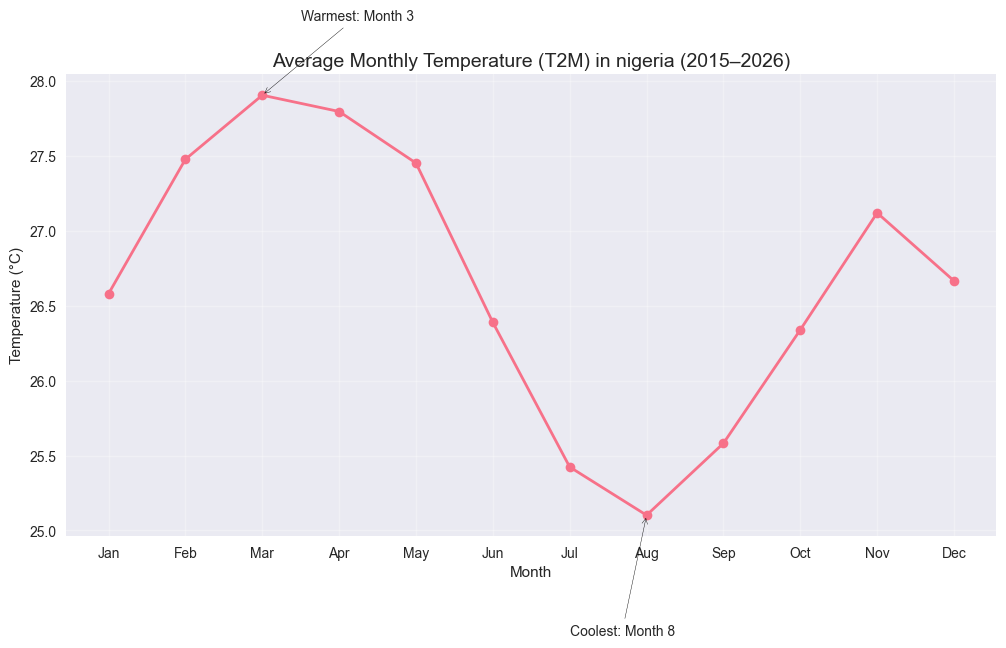

Warmest month on average: Month 3
Coolest month on average: Month 8


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Monthly Average Temperature
monthly_t2m = df.groupby(['Year', 'Month'])['T2M'].mean().reset_index()
monthly_avg_t2m = monthly_t2m.groupby('Month')['T2M'].mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly_avg_t2m.index, monthly_avg_t2m.values, marker='o', linewidth=2)
plt.title('Average Monthly Temperature (T2M) in nigeria (2015–2026)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True, alpha=0.3)

# Annotate warmest and coolest months
warmest_month = monthly_avg_t2m.idxmax()
coolest_month = monthly_avg_t2m.idxmin()
plt.annotate(f'Warmest: Month {warmest_month}', 
             xy=(warmest_month, monthly_avg_t2m.max()), xytext=(warmest_month+0.5, monthly_avg_t2m.max()+0.5),
             arrowprops=dict(arrowstyle='->'))
plt.annotate(f'Coolest: Month {coolest_month}', 
             xy=(coolest_month, monthly_avg_t2m.min()), xytext=(coolest_month-1, monthly_avg_t2m.min()-0.8),
             arrowprops=dict(arrowstyle='->'))

plt.show()

print(f"Warmest month on average: Month {warmest_month}")
print(f"Coolest month on average: Month {coolest_month}")

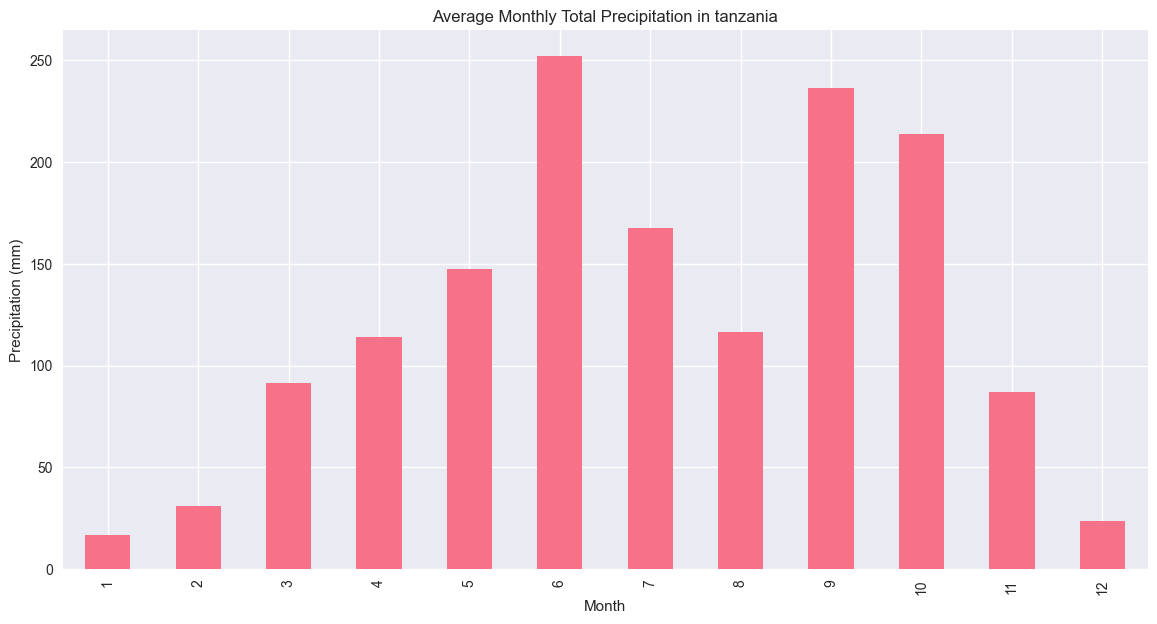

In [11]:
monthly_precip = df.groupby(['Year', 'Month'])['PRECTOTCORR'].sum().unstack(level=1)

plt.figure(figsize=(14, 7))
monthly_precip.mean().plot(kind='bar')
plt.title('Average Monthly Total Precipitation in tanzania')
plt.ylabel('Precipitation (mm)')
plt.xlabel('Month')
plt.grid(True, axis='y')
plt.show()

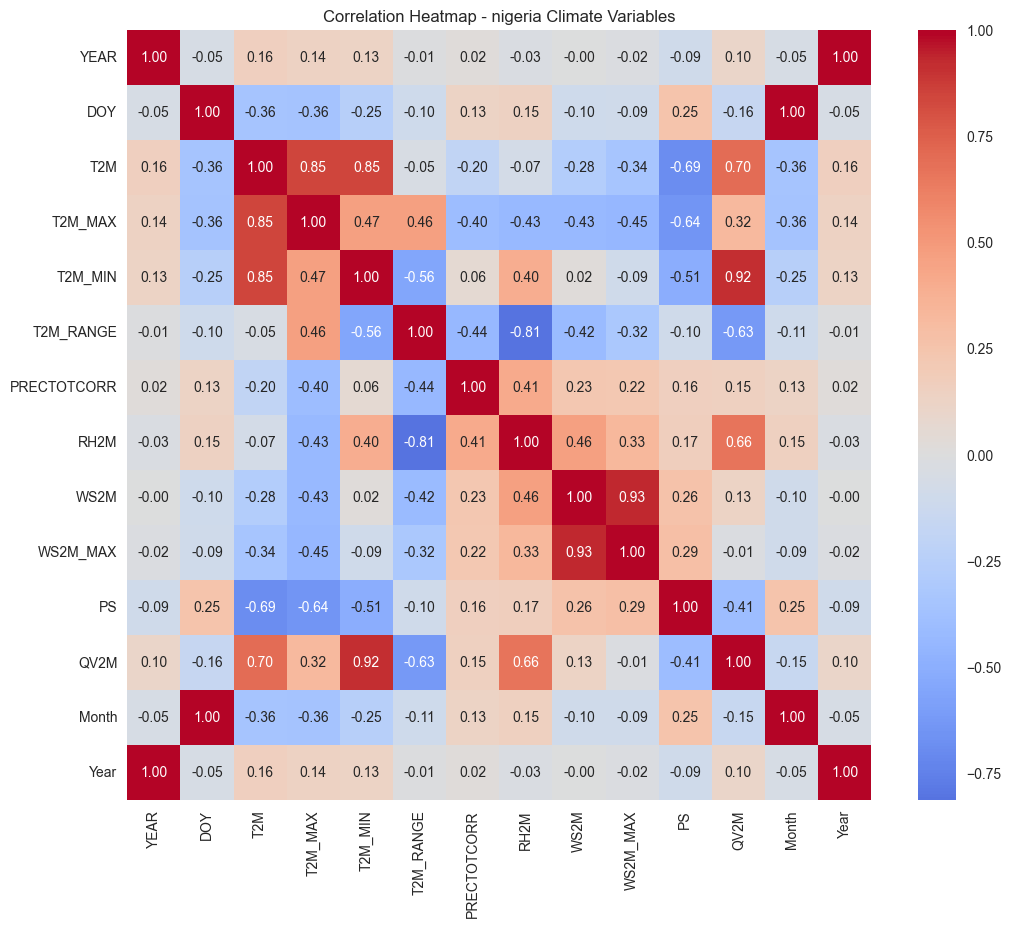

In [12]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap - nigeria Climate Variables')
plt.show()

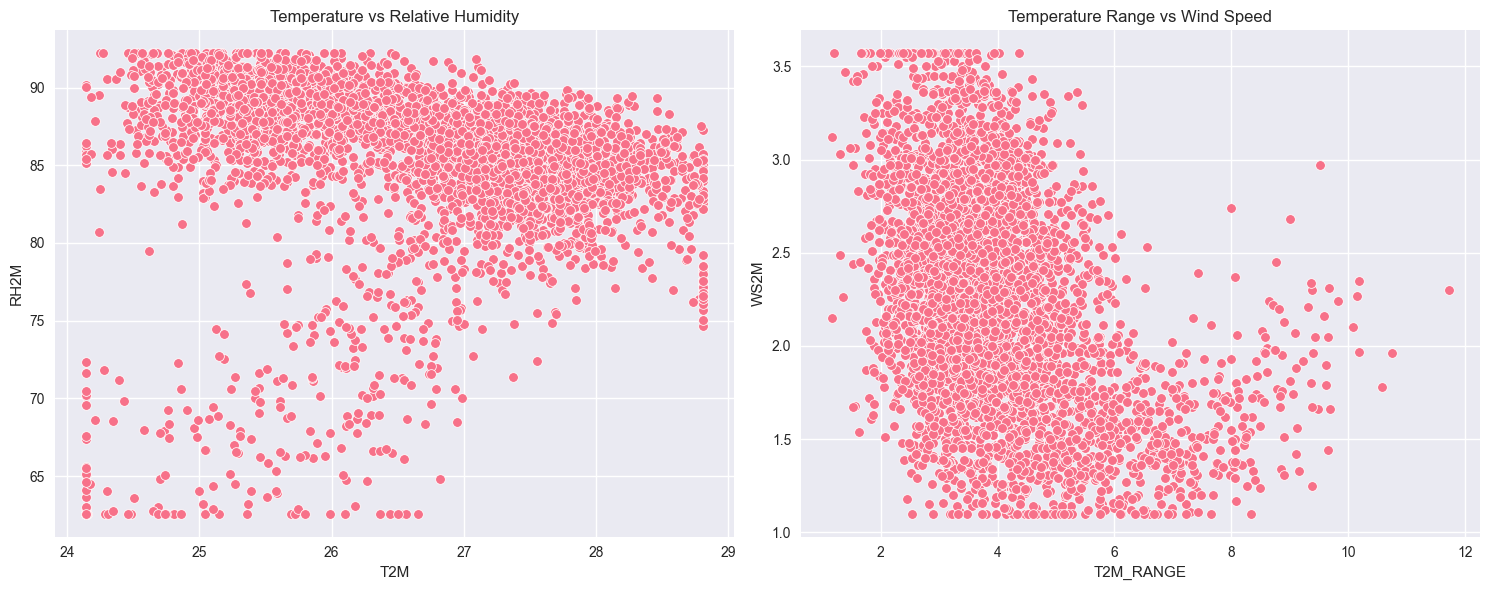

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df, x='T2M', y='RH2M', ax=axes[0])
axes[0].set_title('Temperature vs Relative Humidity')

sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', ax=axes[1])  # Assuming T2M_RANGE exists
axes[1].set_title('Temperature Range vs Wind Speed')

plt.tight_layout()
plt.show()

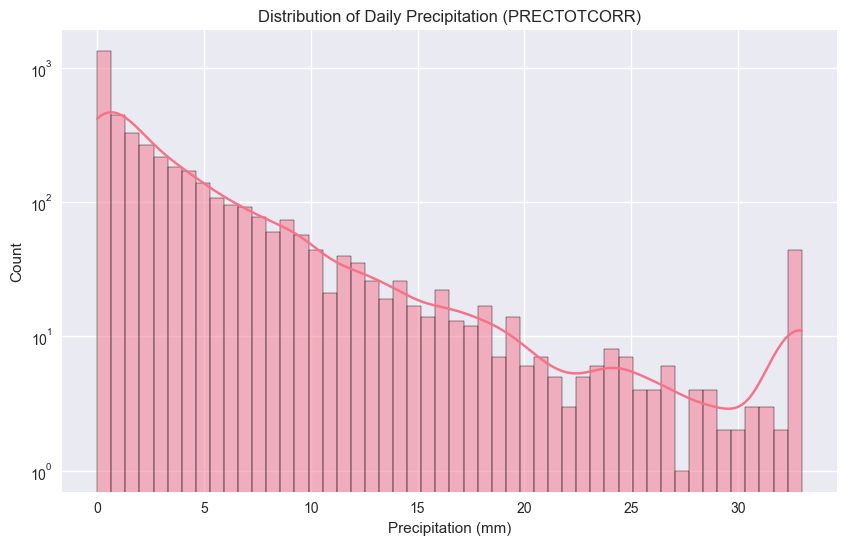

In [14]:
# Histogram of Precipitation
plt.figure(figsize=(10, 6))
sns.histplot(df['PRECTOTCORR'], bins=50, kde=True)
plt.title('Distribution of Daily Precipitation (PRECTOTCORR)')
plt.xlabel('Precipitation (mm)')
plt.yscale('log')   # if heavily skewed
plt.show()

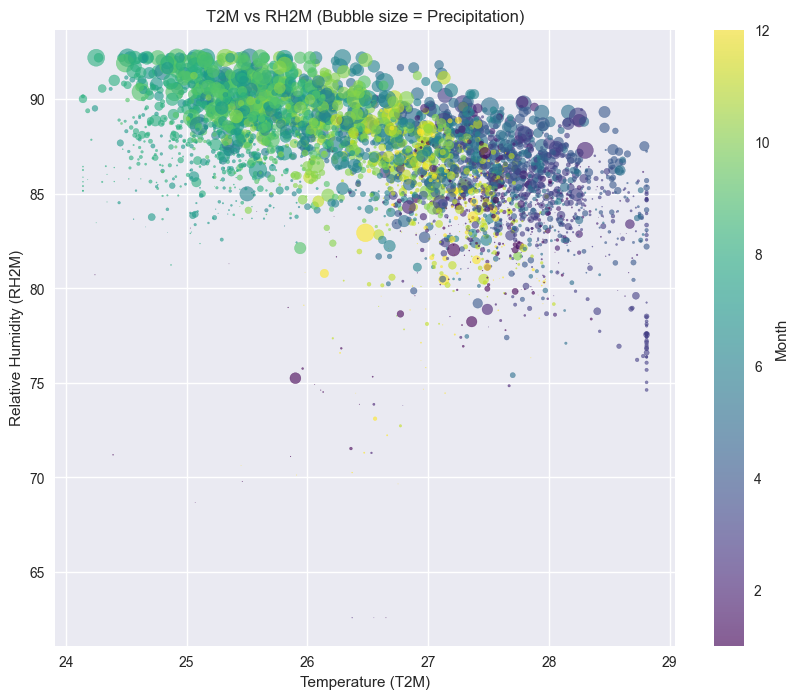

In [15]:
plt.figure(figsize=(10, 8))
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR']*5, alpha=0.6, c=df['Month'], cmap='viridis')
plt.colorbar(label='Month')
plt.xlabel('Temperature (T2M)')
plt.ylabel('Relative Humidity (RH2M)')
plt.title('T2M vs RH2M (Bubble size = Precipitation)')
plt.show()